In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots  # noqa

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
START = 0

In [6]:
def _set_edge_ticks(ax, n=4):
    ymin, ymax = ax.get_ylim()
    ax.set_yticks(np.linspace(ymin, ymax, n + 1))

In [7]:
def _set_limits(ax, df, coll, margin, factor):
    ax.set_ylim(max(np.floor((df[coll].min() - margin) / factor) * factor, 0),
                np.ceil((df[coll].max() + margin) / factor) * factor)

In [8]:
def parse_turbostat(filepath):
    samples = []
    current = {}
    header = None

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                    current = {}
                header = parts
                continue

            if header is None:
                continue

            row = dict(zip(header, parts))
            cpu = "system" if row["CPU"] == "-" else f"cpu{row['CPU']}"

            if cpu != "system":
                current[cpu] = int(row["Bzy_MHz"])
            else:
                if "PkgWatt" in row:
                    current["system_pkg_watt"] = float(row["PkgWatt"])

        if current:
            samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df

In [9]:
def parse_pm(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("*** Sampled system activity"):
                if current and any(k.startswith("cpu") for k in current):
                    samples.append(current)
                current = {}
                continue
            if line.startswith("CPU ") and "frequency:" in line:
                parts = line.split()
                current[f"cpu{int(parts[1])}"] = int(parts[3])
                continue
            if line.startswith("CPU Power:"):
                current["system_pkg_watt"] = float(line.split()[2]) / 1000.0

    if current and any(k.startswith("cpu") for k in current):
        samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df


In [10]:
def prec(df, cols, n, q):
    t = stats.t.ppf(q, df=n - 1)

    cv_df = df[cols].copy()
    cv_df = cv_df.replace(0, np.nan)

    x = cv_df.stack().mean()
    s = cv_df.stack().std()

    cv = (s / x) * 100
    d = t * cv / np.sqrt(n)

    return d

In [11]:
GROUP_COLORS = ["#4C9BE8", "#7FB77E", "#E8A04C", "#B07FE8"]
MEDIAN_COLORS = ["#1F4E79", "#2E5E2C", "#8A5A1A", "#5A3A8A"]


def _build_long(dfs, labels, cpu_groups):
    freq_rows, watt_rows = [], []
    for df, label in zip(dfs, labels):
        df = df.iloc[START:].reset_index(drop=True)
        for group, cols in cpu_groups.items():
            freq = df[cols].replace(0, np.nan).to_numpy().ravel()
            freq_rows.append(pd.DataFrame(
                {"dataset": label, "core": group, "freq": freq[~np.isnan(freq)]}))
        watt_rows.append(pd.DataFrame(
            {"dataset": label, "watt": df["system_pkg_watt"].to_numpy()}))
    return (pd.concat(freq_rows, ignore_index=True),
            pd.concat(watt_rows, ignore_index=True))


def _recolor_medians(ax, group_order, median_palette, ref):
    medians = [ln for ln in ax.lines if mpl.colors.same_color(ln.get_color(), ref)]
    medians.sort(key=lambda ln: np.mean(ln.get_xdata()))
    for i, ln in enumerate(medians):
        ln.set_color(median_palette[group_order[i % len(group_order)]])
        ln.set_linewidth(0.8)


def plot_turbostat(dfs, labels, cpu_groups, width, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(width, FIG_HEIGHT_3), layout='constrained', sharex=True,
            gridspec_kw={"height_ratios": [2, 1]})

        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.8,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
            _recolor_medians(ax1, group_order, median_palette, MEDIAN_COLORS[0])
            ax1.legend(loc="best", frameon=False, title=None)
        _set_limits(ax1, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax1, 4)
        ax1.set_ylabel("Częstotliwość\n[MHz]")
        ax1.set_xlabel("")

        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4), ax=ax2, **common)
        _set_limits(ax2, df_watt, "watt", 5, 5)
        _set_edge_ticks(ax2, 2)
        ax2.set_ylabel("Pobór mocy\n[W]")
        ax2.set_xlabel("Benchmark")

        if len(dfs) > 1:
            plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [12]:
def plot_turbostat_line(df, cpu_groups, width, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    single = len(cpu_groups) == 1

    df = df.iloc[START:].reset_index(drop=True)
    x = df.index.to_numpy()

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax1 = plt.subplots(figsize=(width, FIG_HEIGHT_6), layout='constrained')

        freq_series = []
        for i, (group, cols) in enumerate(cpu_groups.items()):
            freq = df[cols].replace(0, np.nan).mean(axis=1).to_numpy()
            ax1.plot(x, freq, linewidth=0.8,
                     color=MEDIAN_COLORS[i % len(MEDIAN_COLORS)],
                     label=None if single else group)
            freq_series.append(freq)

        df_freq = pd.DataFrame({"freq": np.concatenate(freq_series)})
        _set_limits(ax1, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax1, 4)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("Numer próbki")
        if not single:
            ax1.legend(loc="best", frameon=False, title=None)

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [13]:
def plot_compare(dfs, labels, cpu_groups, filename, margin):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_5), layout='constrained')
        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.8,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
            _recolor_medians(ax, group_order, median_palette, MEDIAN_COLORS[0])
            ax.legend(loc="best", frameon=False, title=None)
        _set_limits(ax, df_freq, "freq", margin, 100)
        _set_edge_ticks(ax, 4)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Częstotliwość [MHz]")
        plt.savefig(f'../svg/{filename}_freq_compare.svg', facecolor='white')
        plt.show()

        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_5), layout='constrained')
        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4),
                    ax=ax, **common)
        _set_limits(ax, df_watt, "watt", 5, 5)
        _set_edge_ticks(ax, 4)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Pobór mocy [W]")
        plt.savefig(f'../svg/{filename}_power_compare.svg', facecolor='white')
        plt.show()

In [14]:
def _report_backends(means, maxes, *, label, unit, prec):
    grand = means.mean()
    vmin, vmax = means.min(), means.max()
    dev_pct = max(abs(vmin - grand), abs(vmax - grand)) / grand * 100
    peak = maxes.max()
    peak_backend = maxes.idxmax()

    print(f"{label} per backend:")
    for backend, val in means.items():
        diff_pct = (val - grand) / grand * 100
        print(f"  {backend:<8} {val:.{prec}f} {unit}  "
              f"({diff_pct:+.2f}% od średniej, maks. {maxes[backend]:.{prec}f} {unit})")
    print(f"Zakres średnich: {vmin:.{prec}f}–{vmax:.{prec}f} {unit} (rozrzut {vmax - vmin:.{prec}f} {unit})")
    print(f"Średnia ze średnich: {grand:.{prec}f} {unit}, maks. odchył od średniej: {dev_pct:.2f}%")
    print(f"Maksimum zarejestrowane: {peak:.{prec}f} {unit} ({peak_backend})")
    print()


def compare_backends(dfs, labels, cpu_groups, *, freq_prec=0, watt_prec=2):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)

    if single:
        grp = df_freq.groupby("dataset")["freq"]
        means = grp.mean().reindex(labels)
        maxes = grp.max().reindex(labels)
        _report_backends(means, maxes, label="Częstotliwość", unit="MHz", prec=freq_prec)
    else:
        for group in group_order:
            grp = df_freq[df_freq["core"] == group].groupby("dataset")["freq"]
            means = grp.mean().reindex(labels)
            maxes = grp.max().reindex(labels)
            _report_backends(means, maxes, label=f"Częstotliwość [{group}]",
                             unit="MHz", prec=freq_prec)

    grp = df_watt.groupby("dataset")["watt"]
    means = grp.mean().reindex(labels)
    maxes = grp.max().reindex(labels)
    _report_backends(means, maxes, label="Pobór mocy", unit="W", prec=watt_prec)

In [15]:
search_Scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
search_Sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
search_Avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
search_Avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")

speck_scalar_turbostat = parse_turbostat("../data/turbostat-speck-scalar.txt")
speck_sse2_turbostat = parse_turbostat("../data/turbostat-speck-sse2.txt")
speck_avx2_turbostat = parse_turbostat("../data/turbostat-speck-avx2.txt")
speck_avx512_turbostat = parse_turbostat("../data/turbostat-speck-avx512.txt")

engine_scalar_turbostat = parse_turbostat("../data/turbostat-engine-scalar.txt")
engine_sse2_turbostat = parse_turbostat("../data/turbostat-engine-sse2.txt")
engine_avx2_turbostat = parse_turbostat("../data/turbostat-engine-avx2.txt")
engine_avx512_turbostat = parse_turbostat("../data/turbostat-engine-avx512.txt")

system_scalar_turbostat = parse_turbostat("../data/turbostat-system-scalar.txt")
system_sse2_turbostat = parse_turbostat("../data/turbostat-system-sse2.txt")
system_avx2_turbostat = parse_turbostat("../data/turbostat-system-avx2.txt")
system_avx512_turbostat = parse_turbostat("../data/turbostat-system-avx512.txt")

search_Scalar_pm = parse_pm("../data/pm-search-Scalar.txt")
search_Neon_pm = parse_pm("../data/pm-search-Neon.txt")

speck_scalar_pm = parse_pm("../data/pm-speck-scalar.txt")
speck_neon_pm = parse_pm("../data/pm-speck-neon.txt")

engine_scalar_pm = parse_pm("../data/pm-engine-scalar.txt")
engine_neon_pm = parse_pm("../data/pm-engine-neon.txt")

system_scalar_ecb_pm = parse_pm("../data/pm-system-scalar-ecb.txt")
system_scalar_cbc_pm = parse_pm("../data/pm-system-scalar-cbc.txt")
system_neon_ecb_pm = parse_pm("../data/pm-system-neon-ecb.txt")
system_neon_cbc_pm = parse_pm("../data/pm-system-neon-cbc.txt")

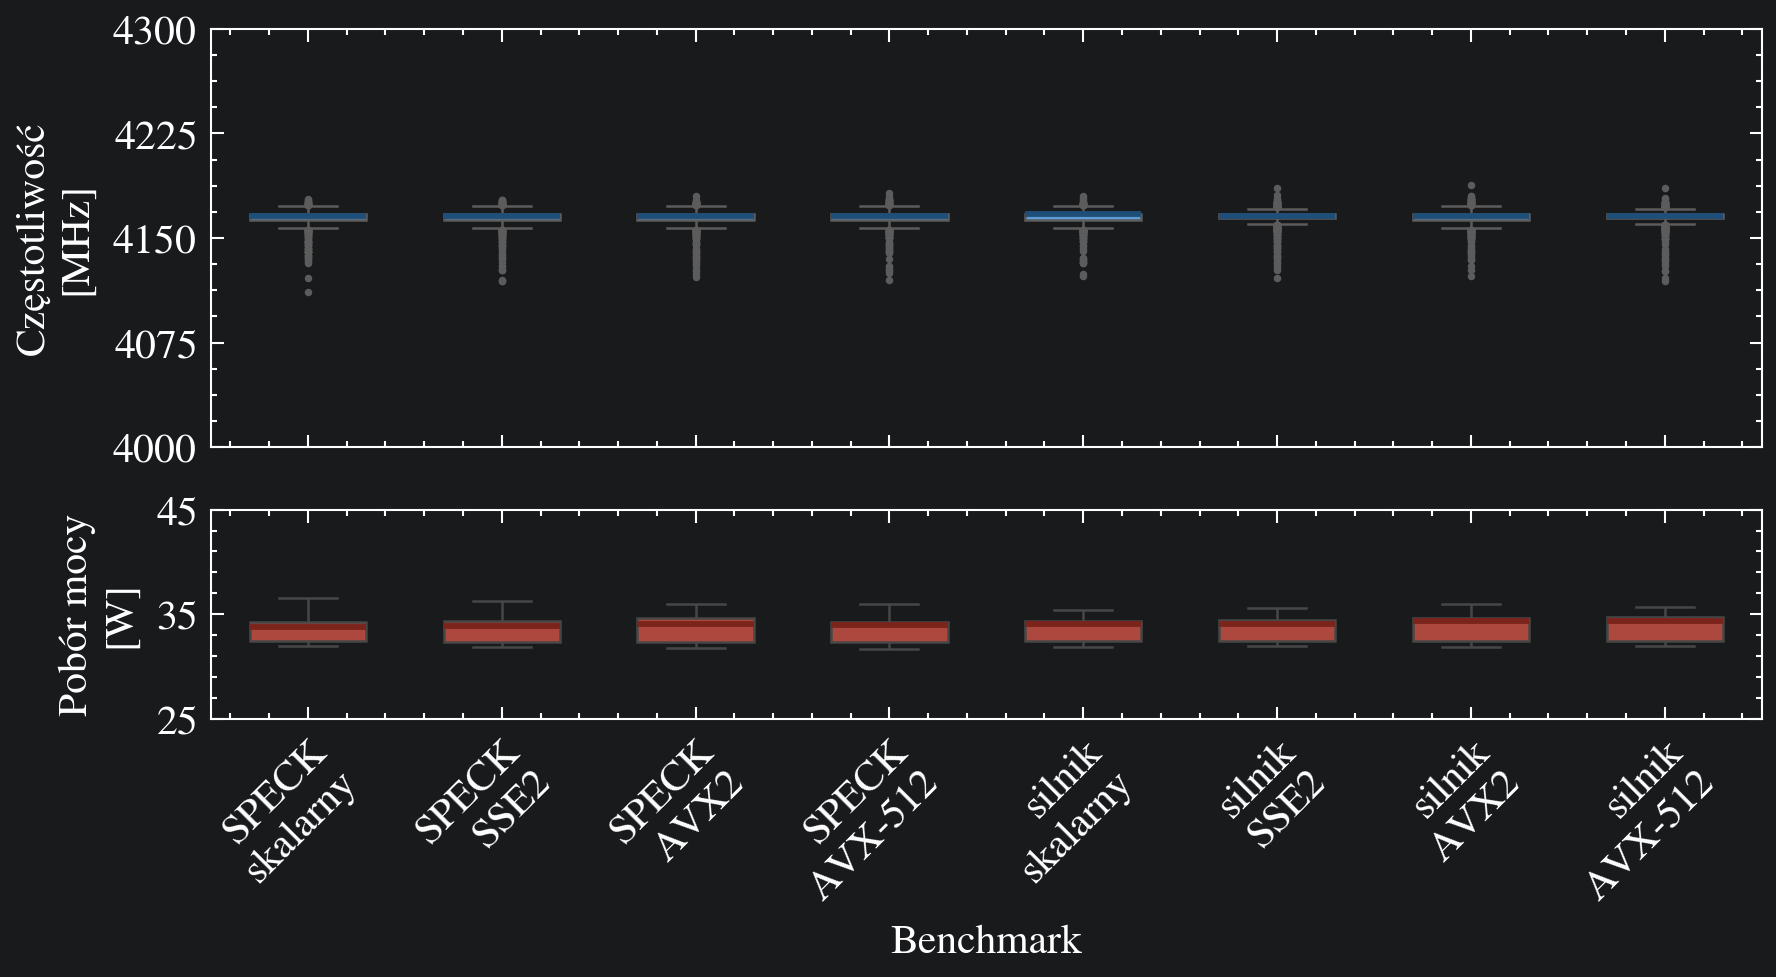

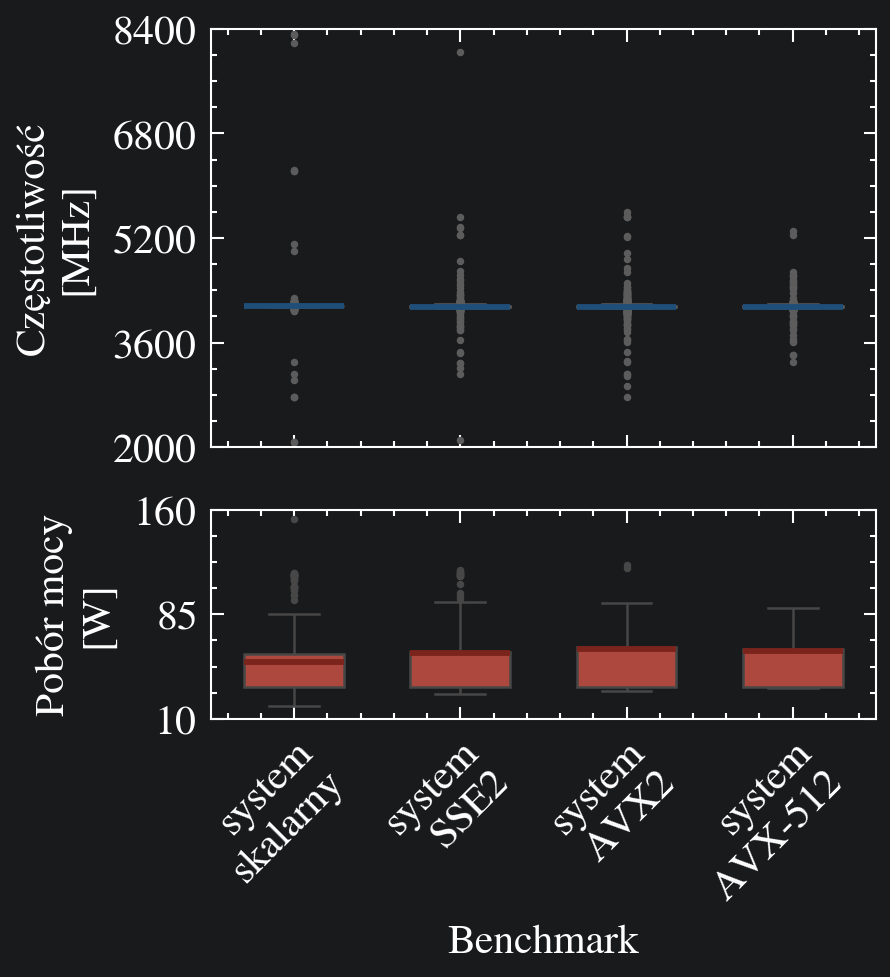

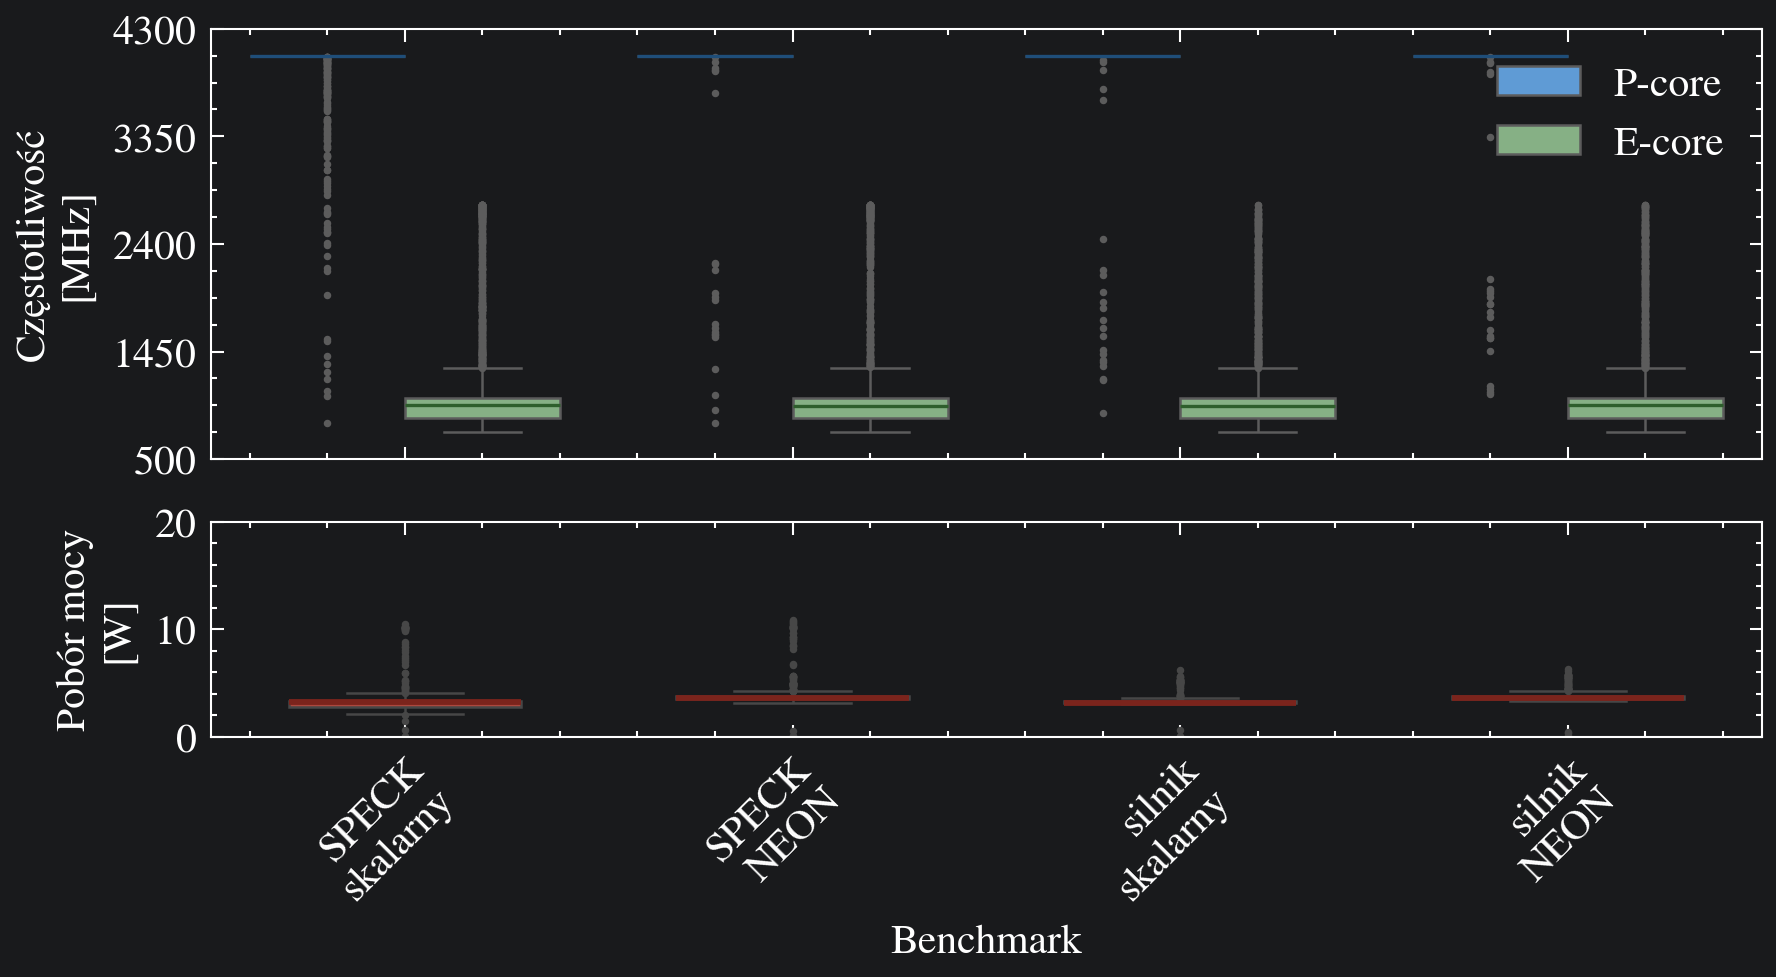

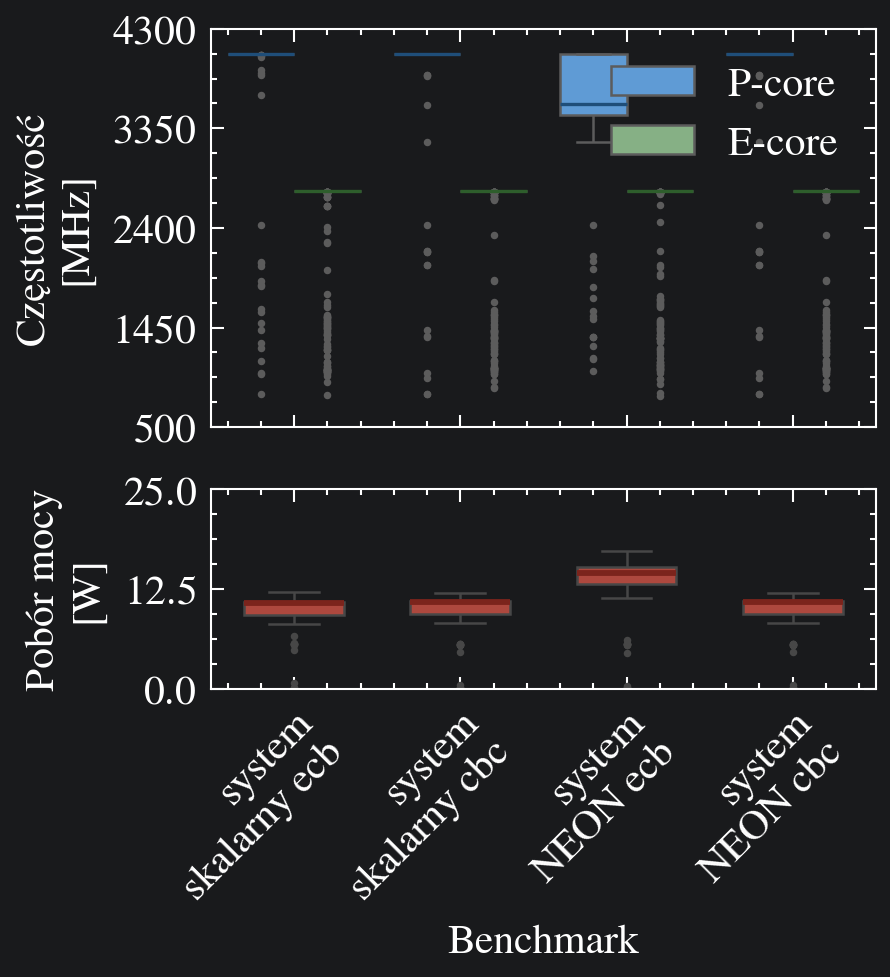

In [16]:
plot_turbostat([speck_scalar_turbostat, speck_sse2_turbostat, speck_avx2_turbostat, speck_avx512_turbostat,
                engine_scalar_turbostat, engine_sse2_turbostat, engine_avx2_turbostat, engine_avx512_turbostat],
               ['SPECK\nskalarny', 'SPECK\nSSE2', 'SPECK\nAVX2', 'SPECK\nAVX-512', 'silnik\nskalarny', 'silnik\nSSE2',
                'silnik\nAVX2', 'silnik\nAVX-512'], [f'cpu{i}' for i in [1, 9]], FIG_WIDTH, "turbostat_speck_engine",
               25)
plot_turbostat([system_scalar_turbostat, system_sse2_turbostat, system_avx2_turbostat, system_avx512_turbostat],
               ['system\nskalarny', 'system\nSSE2', 'system\nAVX2', 'system\nAVX-512'],
               [f'cpu{i}' for i in range(0, 16)], FIG_WIDTH / 2, "turbostat_system_compare", 25)

plot_turbostat([speck_scalar_pm, speck_neon_pm, engine_scalar_pm, engine_neon_pm],
               ['SPECK\nskalarny', 'SPECK\nNEON', 'silnik\nskalarny', 'silnik\nNEON'], {
                   "P-core": [f'cpu{i}' for i in range(4, 8)],
                   "E-core": [f'cpu{i}' for i in range(0, 4)],
               }, FIG_WIDTH, "turbostat_speck_engine", 200)

plot_turbostat([system_scalar_ecb_pm, system_scalar_cbc_pm, system_neon_ecb_pm, system_scalar_cbc_pm],
               ['system\nskalarny ecb', 'system\nskalarny cbc', 'system\nNEON ecb', 'system\nNEON cbc'], {
                   "P-core": [f'cpu{i}' for i in range(4, 8)],
                   "E-core": [f'cpu{i}' for i in range(0, 4)],
               }, FIG_WIDTH / 2, "turbostat_speck_engine", 200)

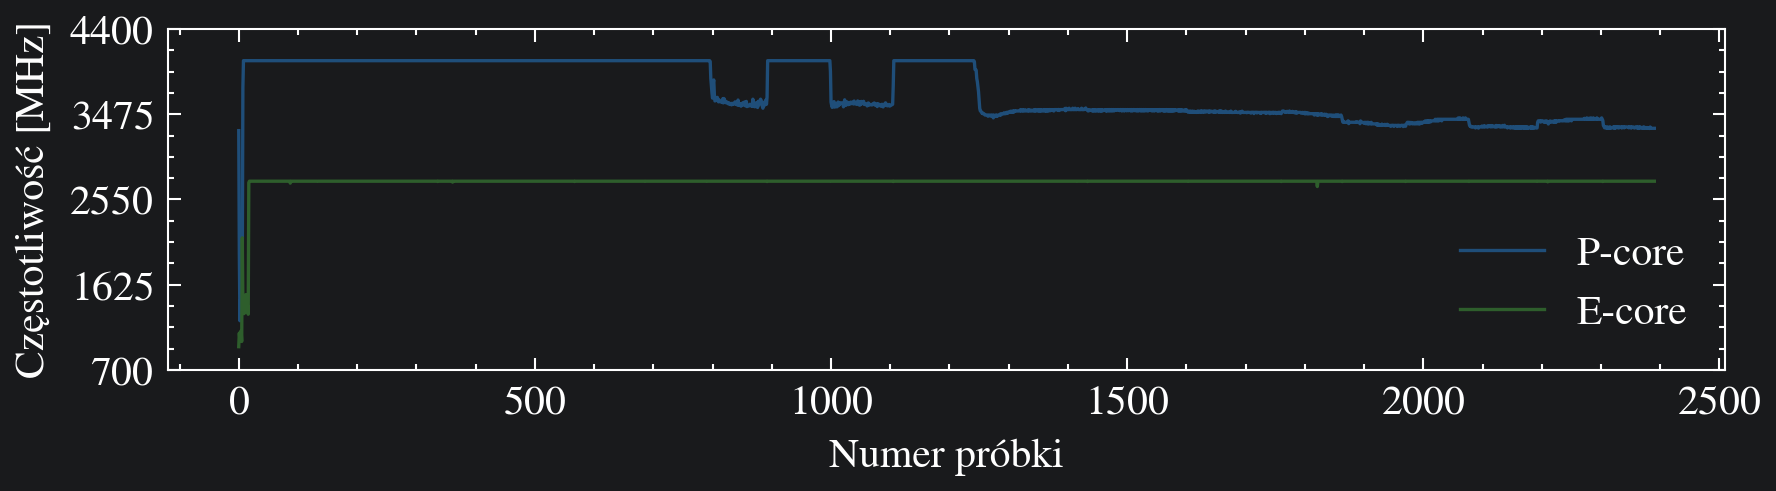

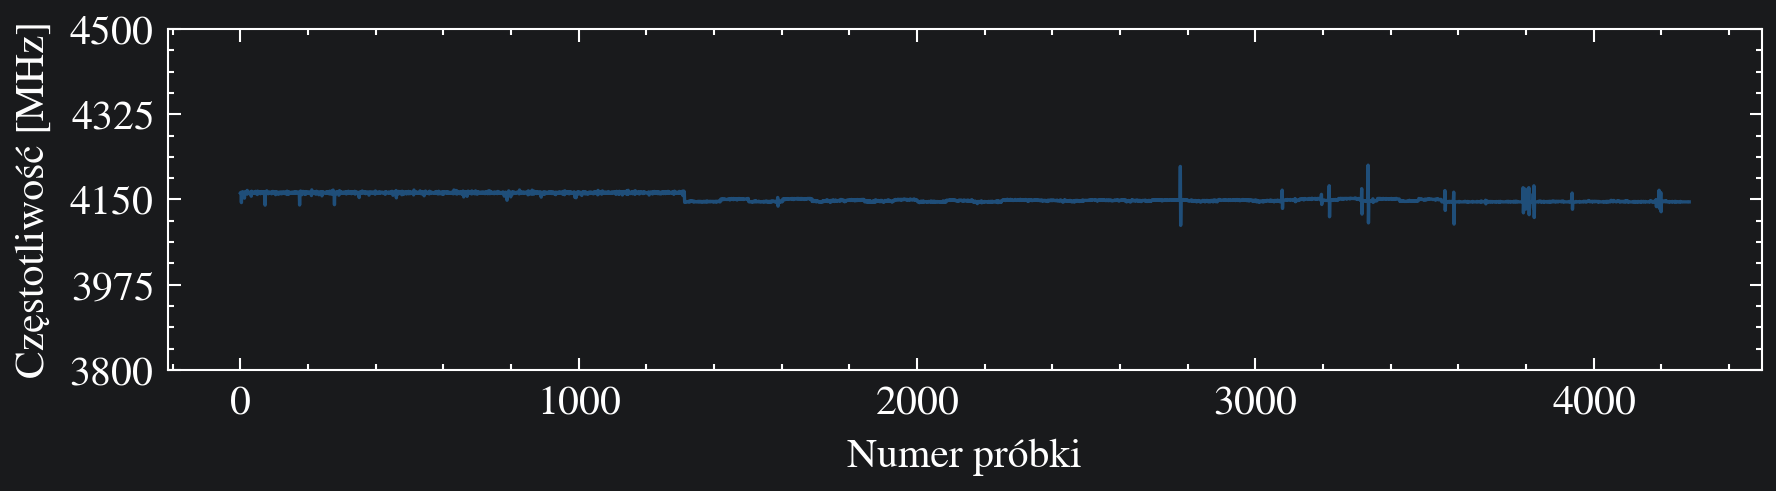

In [17]:
plot_turbostat_line(
    system_neon_cbc_pm,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    }, FIG_WIDTH, "pm_system_line_Speck128_256", 250
)

# plot_turbostat_line(
#     bench_pm,
#     [f'cpu{i}' for i in range(4, 8)], FIG_WIDTH, "pm_bench_line", 250
# )
#

plot_turbostat_line(
    system_avx512_turbostat,
    [f'cpu{i}' for i in range(0, 16)], FIG_WIDTH, "turbostat_compare_line", 250
)

In [18]:
turbostat_backends = {
    "Scalar": search_Scalar_turbostat,
    "SSE2": search_Sse2_turbostat,
    "AVX2": search_Avx2_turbostat,
    "AVX512": search_Avx512_turbostat,
}
turbostat_backend_order = ["Scalar", "SSE2", "AVX2", "AVX512"]

pm_backends = {
    "Scalar": search_Scalar_pm,
    "NEON": search_Neon_pm,
}
pm_backend_order = ["Scalar", "NEON"]

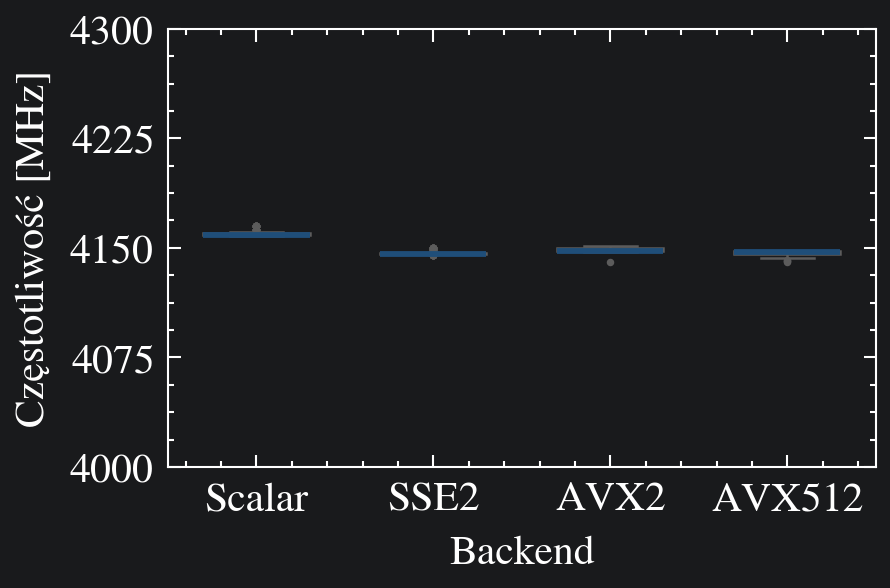

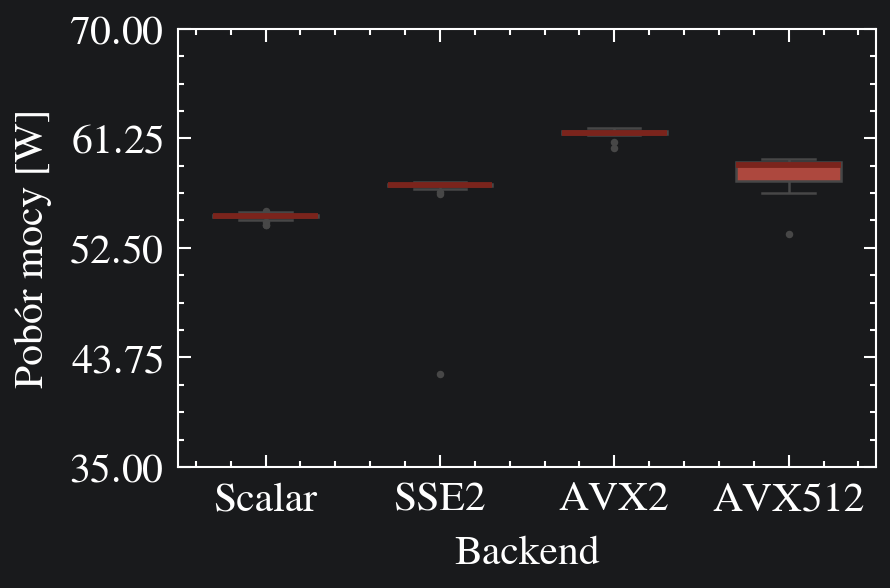

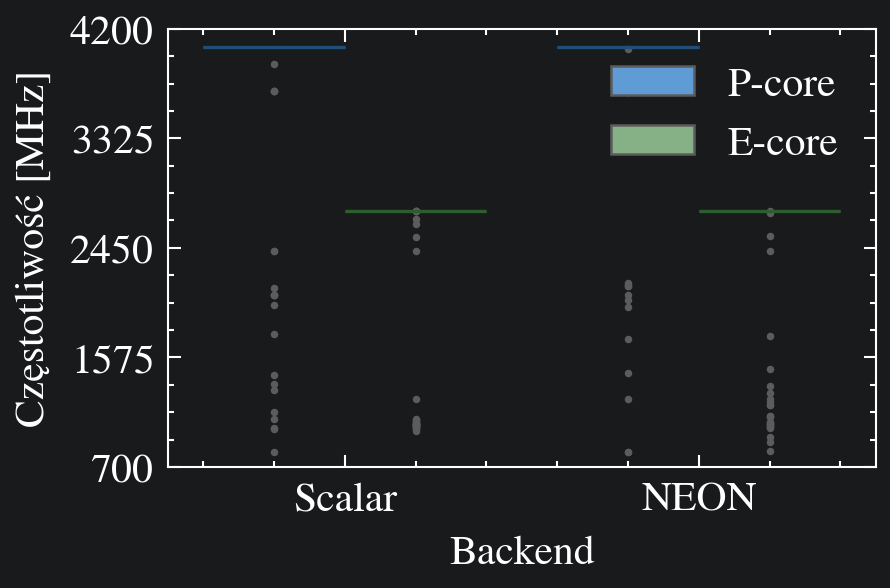

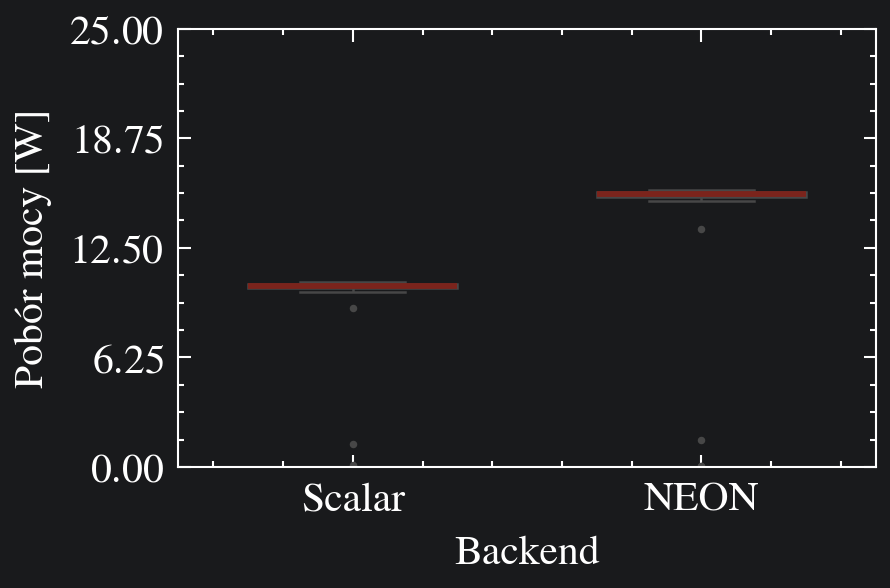

In [19]:
plot_compare(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
    'turbostat',
    100
)

plot_compare(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
    'pm',
    100
)

In [20]:
compare_backends(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
)

compare_backends(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
)

Częstotliwość per backend:
  Scalar   4160 MHz  (+0.23% od średniej, maks. 4165 MHz)
  SSE2     4146 MHz  (-0.09% od średniej, maks. 4150 MHz)
  AVX2     4149 MHz  (-0.04% od średniej, maks. 4151 MHz)
  AVX512   4147 MHz  (-0.09% od średniej, maks. 4148 MHz)
Zakres średnich: 4146–4160 MHz (rozrzut 14 MHz)
Średnia ze średnich: 4150 MHz, maks. odchył od średniej: 0.23%
Maksimum zarejestrowane: 4165 MHz (Scalar)

Pobór mocy per backend:
  Scalar   55.04 W  (-5.13% od średniej, maks. 55.44 W)
  SSE2     57.05 W  (-1.67% od średniej, maks. 57.75 W)
  AVX2     61.65 W  (+6.26% od średniej, maks. 62.04 W)
  AVX512   58.33 W  (+0.53% od średniej, maks. 59.62 W)
Zakres średnich: 55.04–61.65 W (rozrzut 6.60 W)
Średnia ze średnich: 58.02 W, maks. odchył od średniej: 6.26%
Maksimum zarejestrowane: 62.04 W (AVX2)

Częstotliwość [P-core] per backend:
  Scalar   3984 MHz  (+0.30% od średniej, maks. 4056 MHz)
  NEON     3960 MHz  (-0.30% od średniej, maks. 4056 MHz)
Zakres średnich: 3960–3984 MHz (roz

In [21]:
TREND_PCT_THRESHOLD = 0.5

PM_GROUPS = {
    "P-core": [f"cpu{i}" for i in range(4, 8)],
    "E-core": [f"cpu{i}" for i in range(0, 4)],
}

single_core_x86 = [f"cpu{i}" for i in [1, 9]]
p_core_aarch64 = [f"cpu{i}" for i in range(4, 8)]

datasets = [
    ("Speck skalarny", (speck_scalar_turbostat, single_core_x86, None, "x86_64")),
    ("Speck sse2", (speck_sse2_turbostat, single_core_x86, None, "x86_64")),
    ("Speck avx2", (speck_avx2_turbostat, single_core_x86, None, "x86_64")),
    ("Speck avx512", (speck_avx512_turbostat, single_core_x86, None, "x86_64")),
    ("silnik skalarny", (engine_scalar_turbostat, single_core_x86, None, "x86_64")),
    ("silnik sse2", (engine_sse2_turbostat, single_core_x86, None, "x86_64")),
    ("silnik avx2", (engine_avx2_turbostat, single_core_x86, None, "x86_64")),
    ("silnik avx512", (engine_avx512_turbostat, single_core_x86, None, "x86_64")),
    ("system skalarny", (system_scalar_turbostat, None, None, "x86_64")),
    ("system sse2", (system_sse2_turbostat, None, None, "x86_64")),
    ("system avx2", (system_avx2_turbostat, None, None, "x86_64")),
    ("system avx512", (system_avx512_turbostat, None, None, "x86_64")),
    ("Speck skalarny", (speck_scalar_pm, p_core_aarch64, PM_GROUPS, "aarch64")),
    ("Speck neon", (speck_neon_pm, p_core_aarch64, PM_GROUPS, "aarch64")),
    ("silnik skalarny", (engine_scalar_pm, p_core_aarch64, PM_GROUPS, "aarch64")),
    ("silnik neon", (engine_neon_pm, p_core_aarch64, PM_GROUPS, "aarch64")),
    ("system skalarny ecb", (system_scalar_ecb_pm, None, PM_GROUPS, "aarch64")),
    ("system skalarny cbc", (system_scalar_cbc_pm, None, PM_GROUPS, "aarch64")),
    ("system neon ecb", (system_neon_ecb_pm, None, PM_GROUPS, "aarch64")),
    ("system neon cbc", (system_neon_cbc_pm, None, PM_GROUPS, "aarch64")),
]

In [22]:
def _get_freq(df, cols, start=START):
    if cols is None:
        return df.iloc[start:]["system"].replace(0, np.nan).dropna()
    return df.iloc[start:][cols].replace(0, np.nan).mean(axis=1).dropna()

In [23]:
def fmt_p(p):
    if np.isnan(p):
        return "n/d"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

In [24]:
def fmt_median_iqr(med, q1, q3):
    if pd.isna(med) or med <= 0:
        return "--"
    if pd.isna(q1) or pd.isna(q3):
        return rf"\({med:.0f}\)"
    up = (q3 / med - 1.0) * 100
    dn = (1.0 - q1 / med) * 100
    return rf"\({med:.0f}\,(^{{+{up:.1f}\%}}_{{-{dn:.1f}\%}})\)"


trend_rows = []
for name, (df, cols, groups, arch) in datasets:
    freq = _get_freq(df, cols, 0)
    n = len(freq)
    if n < 3:
        continue
    x = np.arange(n, dtype=float)
    tau, p_value = stats.kendalltau(x, freq.values)
    slope_sen = stats.theilslopes(freq.values, x).slope
    slope_pct = slope_sen / freq.mean() * 100
    total_pct = slope_sen * (n - 1) / freq.mean() * 100
    statistically_significant = not np.isnan(p_value) and p_value < 0.05
    practically_significant = abs(total_pct) >= TREND_PCT_THRESHOLD
    if statistically_significant and practically_significant:
        trend = "rosnący" if tau > 0 else "malej."
    else:
        trend = "stab."

    row = {
        "name": name,
        "n": n,
        "total": f"{round(total_pct, 2):.2f}",
        "tau": f"{round(tau, 2):.2f}" if not np.isnan(tau) else None,
        "p": fmt_p(p_value),
        "trend": trend,
        "arch": arch,
    }

    if groups:
        series = []
        for i, (label, group_cols) in enumerate(groups.items()):
            suffix = "" if i == 0 else f" {label}"
            gcols = [c for c in group_cols if c in df.columns]
            series.append((suffix, _get_freq(df, gcols) if gcols else None))
    else:
        series = [("", freq)]

    for suffix, s in series:
        if s is None:
            row[f"median{suffix}"] = "--"
            continue
        med = s.median()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        row[f"median{suffix}"] = fmt_median_iqr(med, q1, q3)

    trend_rows.append(row)

col_order = ["name", "n", "slope_sen", "total", "tau", "p", "trend",
             "median", "median E-core", "arch"]
df_trend = pd.DataFrame(trend_rows)
df_trend = df_trend.reindex(columns=[c for c in col_order if c in df_trend.columns])
df_trend = df_trend.fillna("n/d")
df_trend

,name,n,total,tau,p,trend,median,median E-core,arch
0,Speck skalarny,2765,0.02,0.10,<0.001,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
1,Speck sse2,2749,0.03,0.13,<0.001,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
2,Speck avx2,2769,0.00,0.03,0.051,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
3,Speck avx512,2817,0.00,0.05,<0.001,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
4,silnik skalarny,3257,0.00,-0.03,0.019,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
5,silnik sse2,3076,0.00,0.00,0.970,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
6,silnik avx2,2871,-0.02,-0.07,<0.001,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
7,silnik avx512,2902,-0.02,-0.08,<0.001,stab.,"\(4166\,(^{+0.0\%}_{-0.0\%})\)",n/d,x86_64
8,system skalarny,3143,-0.22,-0.55,<0.001,stab.,"\(4160\,(^{+0.1\%}_{-0.0\%})\)",n/d,x86_64
9,system sse2,3650,-0.43,-0.38,<0.001,stab.,"\(4151\,(^{+0.3\%}_{-0.1\%})\)",n/d,x86_64


In [25]:
df_trend.to_csv(f'../csv/system_trend.csv', index=False)